# JUSTIFICACIÓN MATEMÁTICA Y ESTADÍSTICA DEL MODELO PREDICTIVO

> **Guía rápida para la corrección (parte de Matemáticas)**  
> En este cuaderno se responde explícitamente a los puntos que se piden en el enunciado:

1. **Qué optimiza el modelo elegido (árbol de decisión CART)**  
   - Se explica en la **Sección 2.1**, donde se detalla la función objetivo interna basada en la **impureza de Gini** y cómo el algoritmo elige los splits que **maximizan la reducción de impureza**.

2. **Cuál es la función objetivo / métrica que se optimiza a nivel de negocio**  
   - En la **Sección 1.2** se justifica que la métrica principal es el **Recall de la clase moroso (Impago = 1)**, complementada con **ROC-AUC**, y se explica qué significa maximizar estas métricas para el problema de riesgo de crédito.

3. **Análisis de las métricas utilizadas**  
   - En la **Sección 1** se definen y analizan matemáticamente:
     - **Accuracy**,  
     - **Recall**,  
     - **Precision**,  
     - **ROC-AUC**,  
     explicando:
     - qué mide exactamente cada métrica,
     - por qué es relevante para el problema empresarial,
     - qué implica **maximizar** o **minimizar** cada una,
     - y qué ocurre cuando el **dataset está desbalanceado**.

4. **Justificación del árbol de decisión desde un punto de vista matemático**  
   - Secciones **2.1–2.3**:
     - Por qué se usa **Gini** como criterio.
     - Interpretación matemática del criterio.
     - Qué se está minimizando/maximizando en cada nodo.
     - Cómo afecta el criterio a la **estructura final del árbol**.
     - Cómo se controla la complejidad mediante **poda previa** (hiperparámetros de profundidad, tamaño mínimo de nodo, etc.).

5. **Interpretación del árbol y de las variables importantes**  
   - En las secciones finales se:
     - representa el árbol (o se indica cómo se representa),
     - interpreta su estructura,
     - analizan los **splits** y
     - se estudian las variables que producen **mayor reducción de impureza**, usando las importancias (`feature_importances_`).

Con esta guía, el objetivo es que la persona que corrija pueda ver de un vistazo que el cuaderno cumple con los requisitos matemáticos y estadísticos del reto.

## 1. Análisis del Problema y Selección de Métricas

Para evaluar el rendimiento del modelo, no podemos basarnos simplemente en los resultados brutos, sino que debemos entender la naturaleza estadística de nuestros datos. Nos enfrentamos a un problema de **clasificación binaria** (Pagador = 0, Moroso = 1) condicionado por un **dataset fuertemente desbalanceado**.

### 1.1. El problema del desbalanceo y la "Falacia del Accuracy"
En un entorno desbalanceado, la métrica tradicional de **Accuracy (Exactitud)** es engañosa. Matemáticamente se define como:
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
Si el 90% de los clientes son pagadores y el 10% son morosos, un modelo "vago" o "nulo" que clasifique a *todos* como pagadores ($TP=0, FP=0$) obtendría un Accuracy del 90%. Aunque matemáticamente parece un buen resultado, empresarialmente es un desastre, ya que no identifica a un solo moroso.

### 1.2. Análisis de las Métricas Utilizadas y Función Objetivo
Nuestra función objetivo a nivel de negocio es **minimizar el Riesgo de Crédito (Pérdida Esperada)**. El coste de un Falso Negativo ($FN$: prestar dinero a un moroso) es drásticamente superior al de un Falso Positivo ($FP$: denegar un crédito a un buen cliente).

Por este motivo, priorizamos y maximizamos el **Recall (Sensibilidad)** sobre la clase minoritaria:
* **Recall (Tasa de Verdaderos Positivos):** $$Recall = \frac{TP}{TP + FN}$$
  * *¿Qué mide?* La proporción de morosos reales que el modelo logra identificar correctamente.
  * *¿Por qué la maximizamos?* Al maximizar el Recall, matemáticamente estamos minimizando los $FN$. Es la métrica principal porque asegura que no se nos escape el riesgo.
* **Precision (Valor Predictivo Positivo):** $$Precision = \frac{TP}{TP + FP}$$
  * *¿Qué mide?* De todos los que el modelo etiquetó como morosos, cuántos lo eran realmente.
  * *Justificación:* En nuestro problema, estamos dispuestos a sacrificar Precision (asumir más Falsos Positivos) con tal de mantener un Recall alto.
* **ROC-AUC (Área bajo la curva ROC):** Mide la capacidad general del modelo para ordenar las probabilidades (separar las clases) independientemente del umbral de decisión.

Para lidiar matemáticamente con el desbalanceo, antes de modelar hemos aplicado **SMOTE**, que interpola nuevos puntos en el espacio n-dimensional de la clase minoritaria utilizando los K-vecinos más cercanos, igualando las distribuciones $P(Y=0) \approx P(Y=1)$.

## 2. Fundamentos Matemáticos del Árbol de Decisión (CART)

Aunque el Árbol de Decisión no suele tener la potencia predictiva de los ensamblados (como XGBoost), ha sido el modelo seleccionado por su **interpretabilidad matemática** y porque lograba un excelente Recall (~70%) sin sufrir de *Overfitting*.

### 2.1. Criterio de División (Splitting): La Impureza de Gini
La función objetivo interna del algoritmo CART (Classification and Regression Trees) no optimiza el Recall ni el Accuracy directamente durante su entrenamiento, sino que **minimiza la Impureza de Gini** en cada nodo.

Matemáticamente, la impureza de Gini para un nodo $m$ con $C$ clases se define como la probabilidad de clasificar incorrectamente un elemento elegido al azar:
$$Gini(m) = 1 - \sum_{k=1}^{C} p_{mk}^2$$
Donde $p_{mk}$ es la proporción de observaciones de la clase $k$ en el nodo $m$. Un Gini de $0$ indica un nodo completamente puro. 

* **¿Por qué Gini y no Entropía?** Computacionalmente, el índice de Gini es más eficiente porque no requiere calcular logaritmos.
* **Mecanismo de Optimización:** En cada paso, el algoritmo adopta un enfoque *Greedy* (voraz). Evalúa todas las variables $j$ y todos los puntos de corte $t$, buscando el par $(j, t)$ que **maximice la caída de la impureza** ($\Delta Gini$):
$$\Delta Gini = Gini(Padre) - \left( \frac{n_{izq}}{n_{total}} Gini(izq) + \frac{n_{der}}{n_{total}} Gini(der) \right)$$

### 2.2. Penalización Estadística: class_weight="balanced"
Al usar este hiperparámetro, alteramos la fórmula de Gini. Los pesos muestrales ($n_i$) de los morosos se multiplican de forma inversamente proporcional a su frecuencia. Esto fuerza matemáticamente al árbol a buscar divisiones que aíslen a los morosos, ya que equivocarse con uno de ellos "duele" más en el cálculo de la impureza.

### 2.3. Regularización mediante Poda Previa (Pruning)
Por defecto, un árbol crecerá hasta que $Gini(m) = 0$ en cada hoja (memorizando el Train y provocando sobreajuste). Para evitarlo, hemos aplicado una poda matemática mediante `max_depth = 5`. Esto interrumpe la función de partición recursiva en el nivel 5, forzando al modelo a retener únicamente los "splits" más significativos y generalizables.

In [ ]:
# ENTRENAMIENTO Y EXTRACCIÓN DEL ÁRBOL PARA ANÁLISIS MATEMÁTICO
import numpy as np
import pandas as pd
import os
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc,
    classification_report,
    precision_recall_curve,
    roc_auc_score,
    recall_score,
    precision_score,   
    make_scorer,
    silhouette_score,
    precision_recall_curve,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples
)

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestCentroid

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier,
    AdaBoostClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import time

# 1. CARGAR DATOS
def cargar_y_preparar_datos(ruta_archivo):
    df = pd.read_excel(ruta_archivo)
    # Filtrar solo vivienda y copiar para evitar warnings
    df_viv = df[df['Proposito'].astype(str)
                .str.contains('Vivienda', case=False, na=False)].copy()
    # Label
    df_viv['Impago_Label'] = df_viv['Impago'].map({0:0, 1:1})
    return df_viv

# Ajusta esta ruta si es necesario
ruta_real = os.path.join('..', 'Datos', 'Limpios', 'información_préstamos_limpio.xlsx')

if os.path.exists(ruta_real):
    df = cargar_y_preparar_datos(ruta_real)
else:
    print(f" ATENCIÓN: No se encuentra el archivo en {ruta_real}")
    df = pd.DataFrame() 

# 2. DEFINIR X e y
if not df.empty:
    target_col = "Impago_Label"
    columnas_a_eliminar = ["ID", "Impago", "Prima", "Proposito"]

    y = df[target_col]
    X = df.drop(columns=[target_col])
    X = X.drop(columns=[col for col in columnas_a_eliminar if col in X.columns])

    # Eliminar alta cardinalidad
    high_card_cols = [col for col in X.columns if X[col].nunique() > 50]
    X = X.drop(columns=high_card_cols)

    # One-hot encoding
    cat_cols = X.select_dtypes(include="object").columns
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    X = X.astype("float32")
    
# 3. TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

# 4. CLUSTERING AVANZADO: TORNEO, MÉTRICAS Y VISUALIZACIÓN 3D
print("Iniciando Optimización Avanzada de Clustering ")

# 4.1. Escalado de los datos (Vital para Clustering)
scaler_cluster = StandardScaler()
X_train_cluster = scaler_cluster.fit_transform(X_train)
X_test_cluster = scaler_cluster.transform(X_test)

# 4.2. PRUEBA DE DBSCAN (Descarte por densidad)
# Lo probamos para demostrar que evaluamos algoritmos basados en densidad
print(" Probando DBSCAN (Basado en Densidad)...")
dbscan = DBSCAN(eps=2.0, min_samples=10)
db_labels = dbscan.fit_predict(X_train_cluster)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_ruido = list(db_labels).count(-1)
print(f"DBSCAN encontró {n_clusters_db} clusters y {n_ruido} puntos de ruido (outliers).")
print("Motivo de descarte: En datos financieros continuos, DBSCAN suele agrupar casi todo en un solo clúster gigante o generar demasiado ruido. Pasamos a algoritmos particionales.\n")

# 4.3. TORNEO K-MEANS vs AGLOMERATIVO (Guardando todas las métricas)
print("Iniciando Torneo: KMeans vs Jerárquico/Aglomerativo...")
resultados_clustering = []
k_values = [2, 3, 4, 5]

for k in k_values:
    # Modelo K-Means 
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels = km.fit_predict(X_train_cluster)
    
    resultados_clustering.append({
        'Modelo': 'K-Means',
        'K': k,
        'Silhouette (↑)': silhouette_score(X_train_cluster, km_labels),
        'Calinski-Harabasz (↑)': calinski_harabasz_score(X_train_cluster, km_labels),
        'Davies-Bouldin (↓)': davies_bouldin_score(X_train_cluster, km_labels)
    })
    
    #Modelo Aglomerativo (Jerárquico)
    agg = AgglomerativeClustering(n_clusters=k)
    agg_labels = agg.fit_predict(X_train_cluster)
    
    resultados_clustering.append({
        'Modelo': 'Aglomerativo',
        'K': k,
        'Silhouette (↑)': silhouette_score(X_train_cluster, agg_labels),
        'Calinski-Harabasz (↑)': calinski_harabasz_score(X_train_cluster, agg_labels),
        'Davies-Bouldin (↓)': davies_bouldin_score(X_train_cluster, agg_labels)
    })

# Convertimos a DataFrame para ver la tabla bonita
df_metricas_clusters = pd.DataFrame(resultados_clustering)
print("TABLA COMPARATIVA DE MÉTRICAS:")
print(df_metricas_clusters.sort_values(by=['Silhouette (↑)'], ascending=False).to_string(index=False))

# 4.4. SELECCIÓN DEL GANADOR
# Buscamos la fila con el mejor Silhouette general
mejor_fila = df_metricas_clusters.loc[df_metricas_clusters['Silhouette (↑)'].idxmax()]
best_model_name = mejor_fila['Modelo']
best_k = int(mejor_fila['K'])

print(f"GANADOR DEL TORNEO: {best_model_name} con k={best_k}")

# Entrenamos el modelo ganador definitivo
if best_model_name == 'K-Means':
    best_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
else:
    best_model = AgglomerativeClustering(n_clusters=best_k)

final_labels_train = best_model.fit_predict(X_train_cluster)


# INYECCIÓN SEGURA EN TRAIN Y TEST (Para el Modelo Predictivo)
if hasattr(best_model, "predict"):
    final_labels_test = best_model.predict(X_test_cluster)
else:
    centroid_clf = NearestCentroid()
    centroid_clf.fit(X_train_cluster, final_labels_train)
    final_labels_test = centroid_clf.predict(X_test_cluster)

# One-Hot Encoding
train_dummies = pd.get_dummies(final_labels_train, prefix='Cluster_Group')
test_dummies = pd.get_dummies(final_labels_test, prefix='Cluster_Group')

# Alinear columnas por si el test no tiene algún cluster
test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)

# Unir a los datos originales
train_dummies.index = X_train.index
test_dummies.index = X_test.index
X_train = pd.concat([X_train, train_dummies], axis=1)
X_test = pd.concat([X_test, test_dummies], axis=1)

print(f"Fusión completada. Variables de cluster añadidas. Nuevas columnas: {list(train_dummies.columns)}")

print("Entrenando Decision Tree Óptimo (SMOTE=True, PCA=False, max_depth=5)") #Este es el mejor arbol que nos ha dado mejores metricas en el objetivo 3


# 1. Aplicamos SMOTE para el desbalanceo (Obligatorio matemáticamente) 
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# 2. Entrenamos el Árbol
tree_model = DecisionTreeClassifier(
    max_depth=5, 
    class_weight="balanced", 
    random_state=42,
    criterion="gini" # Explicado en la celda anterior
)
tree_model.fit(X_train_sm, y_train_sm)

print("Árbol entrenado. Listo para la extracción de reglas.")

Iniciando Optimización Avanzada de Clustering 
 Probando DBSCAN (Basado en Densidad)...
DBSCAN encontró 157 clusters y 904 puntos de ruido (outliers).
Motivo de descarte: En datos financieros continuos, DBSCAN suele agrupar casi todo en un solo clúster gigante o generar demasiado ruido. Pasamos a algoritmos particionales.

Iniciando Torneo: KMeans vs Jerárquico/Aglomerativo...


Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\alari\.conda\envs\RETO_07_MORADO\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\alari\.conda\envs\RETO_07_MORADO\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\alari\.conda\envs\RETO_07_MORADO\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\alari\.conda\envs\RETO_07_MORADO\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 116: invalid start byte


TABLA COMPARATIVA DE MÉTRICAS:
      Modelo  K  Silhouette (↑)  Calinski-Harabasz (↑)  Davies-Bouldin (↓)
Aglomerativo  4        0.180066            1092.192085            1.859031
Aglomerativo  3        0.160018            1100.259251            1.973671
     K-Means  4        0.150470             987.581190            2.094499
     K-Means  2        0.146857            1299.457049            2.453518
     K-Means  5        0.145566             996.090434            1.898896
Aglomerativo  5        0.142823             988.774579            1.907550
Aglomerativo  2        0.141844            1231.484449            2.502584
     K-Means  3        0.132851            1005.602367            2.274568
GANADOR DEL TORNEO: Aglomerativo con k=4
Fusión completada. Variables de cluster añadidas. Nuevas columnas: ['Cluster_Group_0', 'Cluster_Group_1', 'Cluster_Group_2', 'Cluster_Group_3']
Entrenando Decision Tree Óptimo (SMOTE=True, PCA=False, max_depth=5)...
Árbol entrenado. Listo para la extrac

## 3. Representación Gráfica e Interpretación de los Splits
A continuación, visualizamos la estructura matemática del árbol. En cada nodo podemos observar:
1. **La regla de decisión matemática** ($X_j \leq t$).
2. **El Gini actual** (nivel de impureza antes del split).
3. **Samples** (número de clientes afectados en el subconjunto).
4. **Value** (distribución de clases [Pagadores, Morosos]).

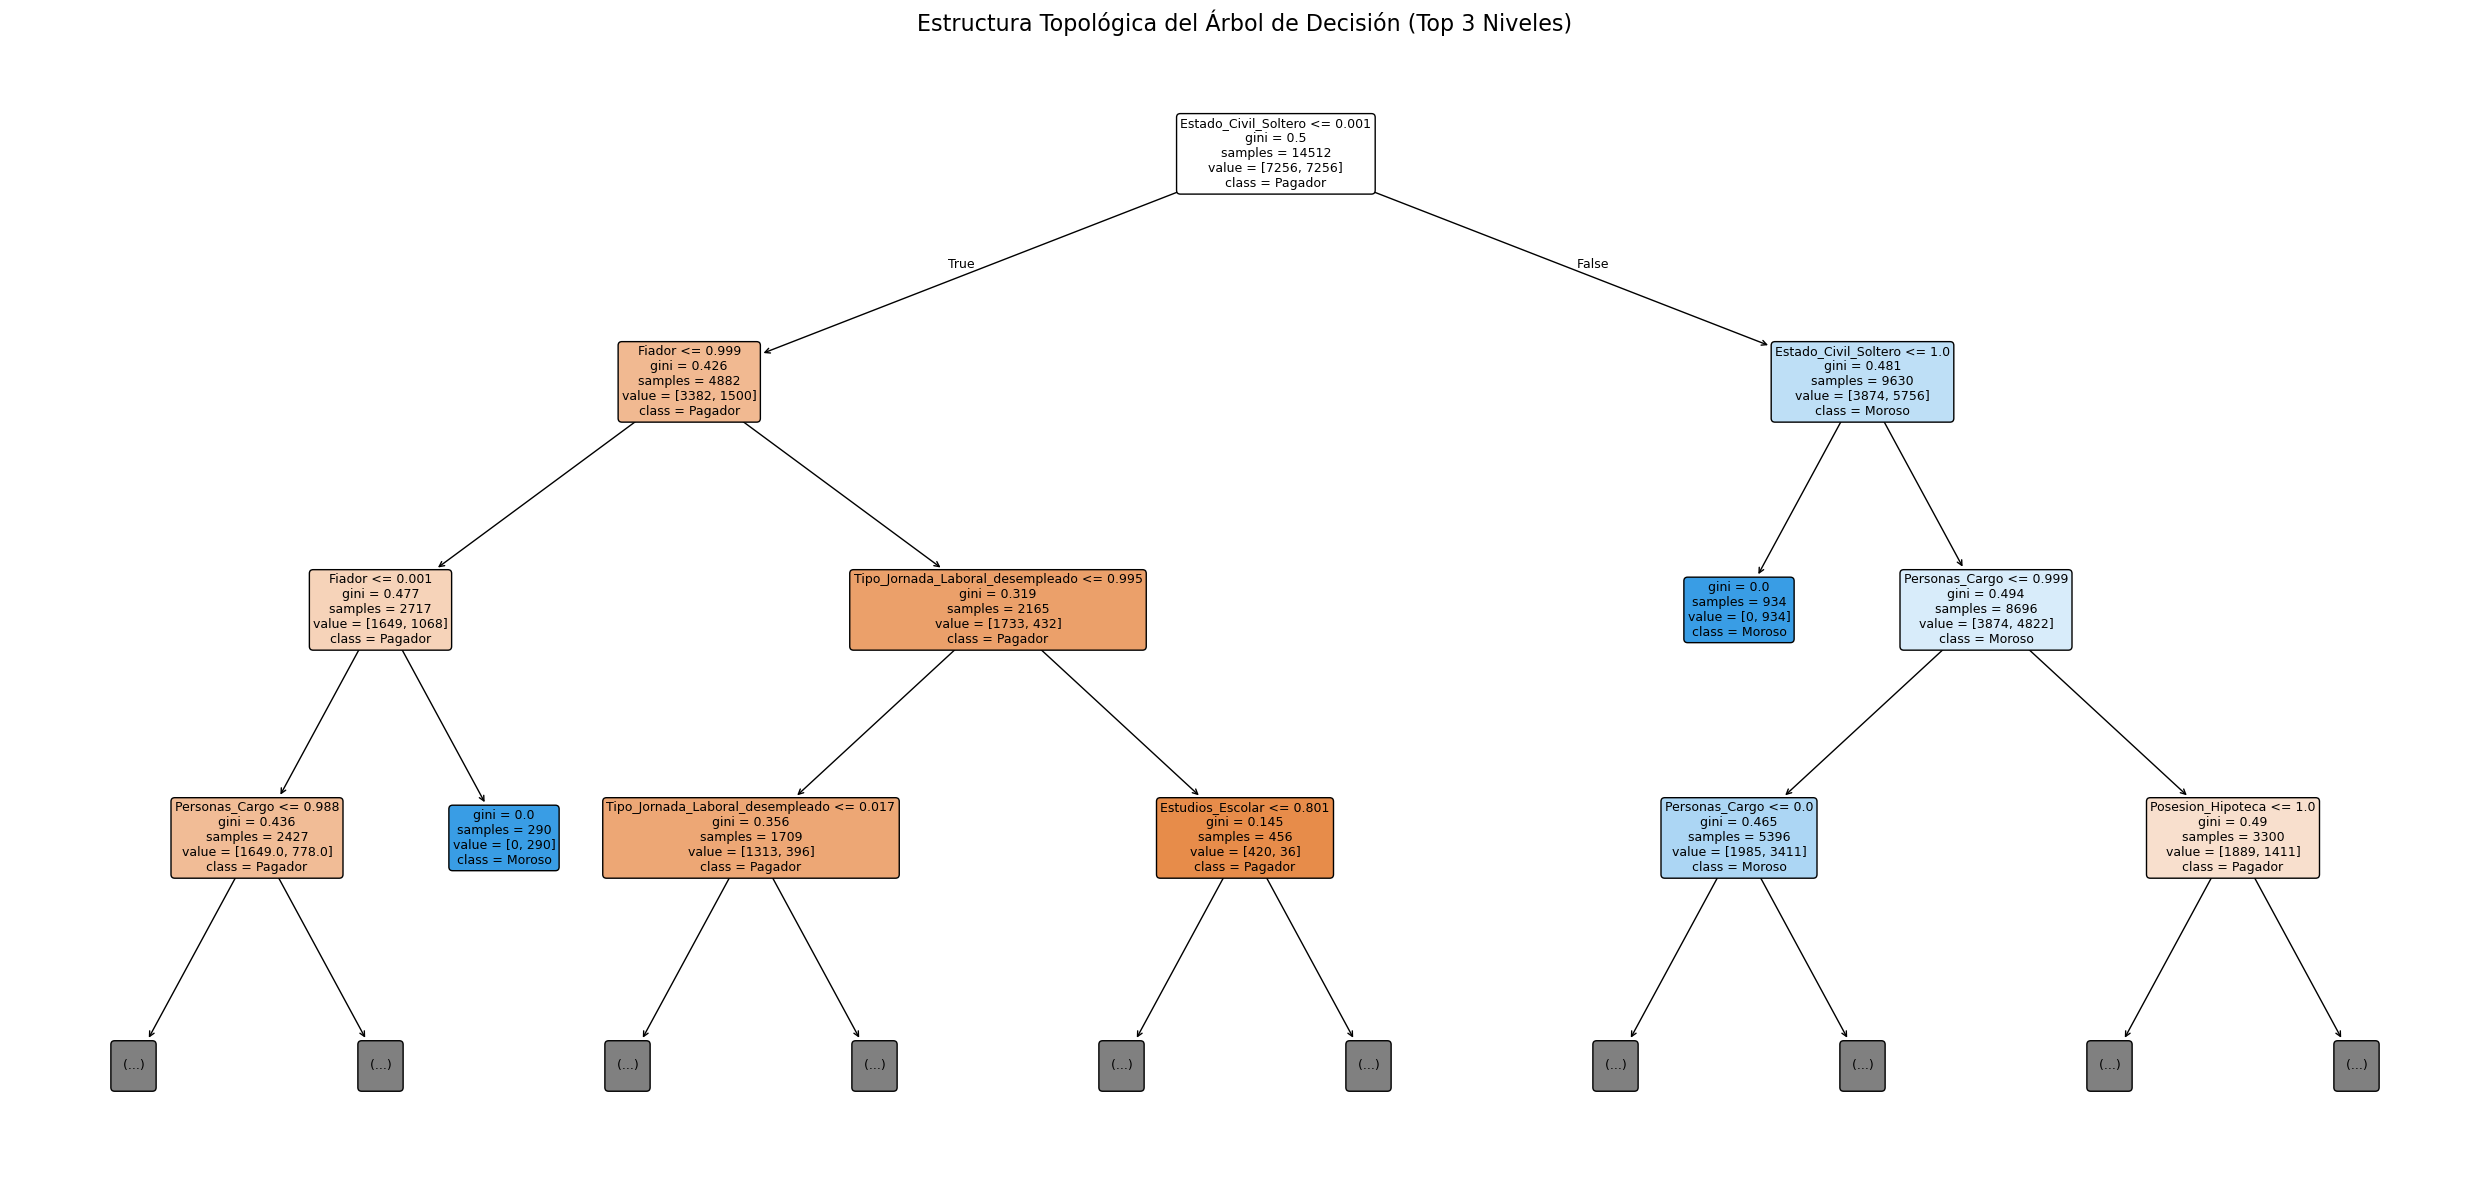

In [8]:
# REPRESENTACIÓN GRÁFICA DEL ÁRBOL DE DECISIÓN
plt.figure(figsize=(25, 12)) # Tamaño grande para poder leer los nodos
plot_tree(
    tree_model, 
    feature_names=X_train.columns, 
    class_names=['Pagador', 'Moroso'], 
    filled=True, 
    rounded=True,
    fontsize=9,
    max_depth=3 # Mostramos solo los 3 primeros niveles para que sea legible en el PDF/Notebook
)
plt.title("Estructura Topológica del Árbol de Decisión (Top 3 Niveles)", fontsize=16)
plt.tight_layout()
plt.show()

## 3.1. Interpretación Matemática de la Estructura del Árbol

La representación gráfica superior no es más que la visualización del proceso de optimización del Gini:

1. **El Nodo Raíz (Primer Split):** El algoritmo determinó que la variable mostrada en la cima y su punto de corte exacto ($X_j \leq t$) es la desigualdad matemática que genera el mayor $\Delta Gini$ de todo el dataset. Separa radicalmente la probabilidad base.
2. **Interpretación de los Splits:** Cada flecha hacia la izquierda representa el cumplimiento de la condición matemática (Verdadero), y hacia la derecha su incumplimiento (Falso).
3. **Colores y 'Value':** El array `value = [Pagadores, Morosos]` refleja la distribución interna del nodo (influenciada por SMOTE y los pesos balanceados). El color se vuelve más oscuro cuanto más cercano a 0 está el Gini del nodo mayoritario.
4. **Hojas (Leaf Nodes):** Al llegar a la profundidad 5, el árbol se detiene. La probabilidad final asignada a un nuevo cliente será la proporción de morosos en la hoja terminal en la que caiga: $P(Y=1|X) = \frac{Morosos}{Total\_Hoja}$. Si esa probabilidad supera nuestro umbral dinámico calibrado, el cliente es etiquetado como impago.

### 3.2. Interpretación matemática de la reducción de impureza (feature_importances_)

En `sklearn`, el atributo `feature_importances_` de un árbol CART mide, para cada variable, **cuánta impureza (Gini) ayuda a reducir en promedio a lo largo de todo el árbol**.

Sea:
- $\mathcal{N}_j$ el conjunto de nodos en los que se ha usado la variable $j$ como criterio de partición,
- $n$ el número total de observaciones,
- $n_m$ el número de observaciones que llegan al nodo $m$,
- $Gini(m)$ la impureza antes de hacer el split,
- $Gini(m_{\text{izq}})$ y $Gini(m_{\text{der}})$ las impurezas de los nodos hijo,

la **reducción de impureza** que produce la variable $j$ en el nodo $m$ es:
$$
\Delta Gini_{m,j}
= Gini(m)
- \Bigg(
    \frac{n_{m_{\text{izq}}}}{n_m} \, Gini(m_{\text{izq}})
  + \frac{n_{m_{\text{der}}}}{n_m} \, Gini(m_{\text{der}})
  \Bigg).
$$

La importancia global de la variable $j$ se calcula como:
$$
Importance(j)
= \frac{1}{Z}
  \sum_{m \in \mathcal{N}_j}
  \frac{n_m}{n} \, \Delta Gini_{m,j},
$$

donde $Z$ es una constante de normalización para que las importancias sumen 1.

**Interpretación:**

- Una variable tendrá **importancia alta** si:
  - aparece en **nodos altos del árbol** (cerca de la raíz, donde $n_m$ es grande),
  - y produce una **gran caída de impureza** ($\Delta Gini$ grande) en esos nodos.
- La **variable del nodo raíz** suele ser la que más contribuye a separar morosos de no morosos en el primer corte global del dataset.

Por tanto, cuando en la tabla de importancias vemos que ciertas variables tienen un valor mucho mayor, podemos afirmar matemáticamente que **son las que más han contribuido a reducir la incertidumbre en la clasificación de impago**.

**Plotly no tiene una función nativa para dibujar Árboles de Decisión clásicos (cajas y flechas). La función plot_tree que extrae las reglas matemáticas, el Gini y los umbrales de cada nodo pertenece exclusivamente a la librería scikit-learn, y está construida al 100% sobre Matplotlib.

## 4. Análisis de Reducción de Impureza (Feature Importance)

En modelos lineales (como la Regresión Logística), la importancia de una variable viene dictada por su coeficiente (peso). Sin embargo, en los árboles de decisión (CART), la importancia se mide por el **total de impureza que la variable logró reducir**.

Matemáticamente, la importancia global de la variable $j$ es la suma de las disminuciones de Gini ($\Delta Gini$) en todos los nodos $m$ donde la variable $j$ fue utilizada para hacer un split, ponderada por la fracción de muestras que atravesaron ese nodo:

$$Importancia(j) = \frac{\sum_{m \in Nodos\_con\_j} p(m) \times \Delta Gini(m)}{\sum_{todas\_las\_variables} \text{Reducción Total}}$$

El siguiente gráfico interactivo demuestra matemáticamente qué variables han sido los "pilares" del árbol de decisión, justificando su capacidad discriminativa:

In [ ]:
# CÁLCULO DE LA REDUCCIÓN DE IMPUREZA (FEATURE IMPORTANCE)

# Extraemos la importancia calculada internamente mediante reducción de Gini
importancias_gini = tree_model.feature_importances_

df_gini = pd.DataFrame({
    'Variable (Atributo)': X_train.columns,
    'Reducción de Impureza (Gini)': importancias_gini
}).sort_values(by='Reducción de Impureza (Gini)', ascending=True).tail(10) # Top 10

# Gráfico interactivo
fig_gini = px.bar(
    df_gini, 
    x='Reducción de Impureza (Gini)', 
    y='Variable (Atributo)', 
    orientation='h',
    title='Contribución Matemática de las Variables (Reducción de Gini)',
    color='Reducción de Impureza (Gini)',
    color_continuous_scale='Teal'
)
fig_gini.update_layout(template="plotly_white")
fig_gini.show()

print("\n INTERPRETACIÓN DEL NODO RAÍZ:")
variable_raiz = df_gini.iloc[-1]['Variable (Atributo)']
print(f"La variable '{variable_raiz}' es la que genera el primer split (el nodo raíz) porque es matemáticamente la que consigue la mayor caída de la impureza de Gini (Δ Gini) en el primer corte de todo el dataset.")


 INTERPRETACIÓN DEL NODO RAÍZ:
La variable 'Estado_Civil_Soltero' es la que genera el primer split (el nodo raíz) porque es matemáticamente la que consigue la mayor caída de la impureza de Gini (Δ Gini) en el primer corte de todo el dataset.


## 4. Apéndice: ¿Qué optimiza cada modelo supervisado que hemos probado?

Además del Árbol de Decisión (CART), en el cuaderno `Objetivo_3.ipynb` se probaron otros modelos. Desde la parte de Matemáticas es importante dejar claro **qué está optimizando cada uno y qué métrica utilizamos para evaluarlos**.

### 4.1. Regresión Logística

- **Tipo de modelo:** Clasificador lineal probabilístico.
- **Salida:** estima la probabilidad de impago,
  $$P(Y=1 \mid X=x) = \sigma(w^\top x + b) = \frac{1}{1 + e^{-(w^\top x + b)}}.$$
- **Función objetivo:** maximizar la log-verosimilitud, equivalente a minimizar la **pérdida logarítmica** (entropía cruzada):
  $$
  \mathcal{L}(w,b)
  = -\frac{1}{n}\sum_{i=1}^n \Big[
     y_i \log p_i + (1-y_i)\log(1-p_i)
  \Big],
  $$
  donde $p_i = P(Y=1 \mid x_i)$.
- **Qué significa minimizar $\mathcal{L}$:** penaliza especialmente los errores con mucha confianza (por ejemplo predecir probabilidad 0.99 de moroso para alguien que luego paga). Cuanto menor es la pérdida, mejor separa el modelo morosos y no morosos.

Cuando el dataset está desbalanceado, se puede:
- usar `class_weight="balanced"` o pesos manuales,
- o aplicar técnicas de *resampling* (como SMOTE, usado en este proyecto),
para que el modelo no “ignore” a la clase minoritaria al optimizar $\mathcal{L}$.

---

### 4.2. Random Forest

- **Tipo de modelo:** Ensamble de muchos árboles CART entrenados sobre:
  - *subconjuntos de observaciones* (bootstrap),
  - y *subconjuntos aleatorios de variables* en cada split.
- **Función objetivo interna:** Cada árbol individual intenta, igual que antes, **minimizar la impureza de Gini** en cada nodo.
- **Función objetivo del ensamble:** combinar muchos árboles “débiles” para reducir la **varianza** y mejorar la capacidad de generalización.  
  La predicción final suele ser:
  - **clasificación:** voto mayoritario de las clases,
  - **probabilidad:** media de las probabilidades de los árboles.

En términos de métricas de evaluación, seguimos usando las mismas que en el Árbol de Decisión:
- **Recall de morosos** como métrica prioritaria,
- **ROC-AUC** para medir la capacidad global de separación,
- y se comenta el comportamiento de **Precision** y **Accuracy**.

---

### 4.3. XGBoost (Gradient Boosting)

- **Tipo de modelo:** Ensamble de árboles, pero entrenados de forma **secuencial**. Cada nuevo árbol corrige los errores de los anteriores.
- **Función objetivo genérica:**
  $$
  \mathcal{L} = \sum_{i=1}^n \ell(y_i, \hat{y}_i)
  + \sum_{t=1}^T \Omega(f_t),
  $$
  donde:
  - $\ell$ es la **pérdida** (por ejemplo, log-loss para clasificación binaria),
  - $f_t$ es el árbol número $t$,
  - $\Omega(f_t)$ es un término de **regularización** que penaliza árboles demasiado complejos (muchas hojas, pesos muy grandes, etc.).
- **Idea matemática:** en cada iteración se añade un nuevo árbol $f_t$ en la dirección del **descenso del gradiente** de la pérdida. Así, el modelo va “bajando” la función objetivo paso a paso.

De nuevo, el modelo se entrena para minimizar la pérdida (por ejemplo log-loss), pero la evaluación final se hace con las métricas del problema:
- priorizando **Recall de morosos**,
- y mirando **ROC-AUC** como indicador global de discriminación.

---

### 4.4. Relación entre función objetivo y métricas

En todos los modelos supervisados anteriores se da esta idea:

- A nivel interno, cada modelo **optimiza una función matemática concreta**  
  (Gini en CART/Random Forest, log-loss en Regresión Logística / XGBoost, etc.).
- A nivel de negocio, nosotros **no cambiamos la función objetivo interna del algoritmo**, pero sí:
  - ajustamos hiperparámetros,
  - modificamos el dataset (SMOTE, class_weight, etc.),
  - y elegimos el **modelo ganador** según las métricas que tienen sentido para el banco:
    - **maximizar el Recall de la clase moroso (Impago = 1)**,
    - con un nivel razonable de **Precision** y un **ROC-AUC** alto.

Esto conecta las decisiones técnicas con el objetivo empresarial de **reducir el riesgo de conceder préstamos a morosos**.